# Multipacting: a reentrant cavity

A **reentrant** cell — where the equator wall overhangs the iris neck — reaches a higher accelerating gradient than a rounded cell, but the re-entrant nose is a classic multipacting site: the concave geometry can trap the resonant electron avalanche. It is a good stress test for the tracker, whose wall-collision handling copes with the re-entrant (concave) corners.

We use the two-elliptic-arc reentrant TESLA cell of
> V. Shemelin, H. Padamsee, R. L. Geng, *Optimal cells for TESLA accelerating structure*, Nucl. Instrum. Methods A **496** (2003) 1-7,

the most reentrant row of their Table 2 (`delta_e = +50%`), with the TESLA aperture `Ra = 35 mm`. The half-cell length is a quarter RF wavelength, `L = lambda/4`.

In [1]:
import os, tempfile
import numpy as np
import matplotlib.pyplot as plt
from cavsim2d import EllipticalCavity
from cavsim2d.utils.style import apply_style
apply_style()

c0 = 299_792_458.0
L = c0 / 1.3e9 / 4 * 1e3        # lambda/4 at 1.3 GHz, in mm

# [A, B, a, b, Ri, L, Req] (mm) - Shemelin et al. Table 2, delta_e = +50%, Ra = 35 mm
cell = [56.56, 37.12, 6.50, 7.34, 35.0, L, 97.76]

## The reentrant shape

The full (mirrored) cross-section shows the overhanging equator — the wall folds back over the iris, the defining feature of a reentrant cell.

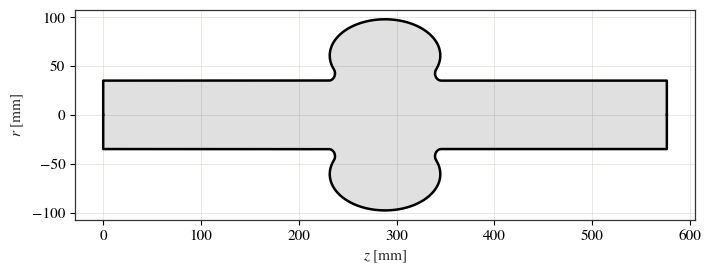

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [2]:
cav = EllipticalCavity(1, cell, cell, cell, beampipe='both', name='reentrant')
cav.set_workspace(os.path.join(tempfile.mkdtemp(), 'reentrant_mp'))
cav.plot('geometry', mirror=True)

## The field

Solve multipacting's own wall-refined field and check the fundamental (a converged TESLA cell is ~1.3 GHz).

In [3]:
mp = cav.multipacting
mp.set_mesh_parameters(h=8, p=3, pec_maxh=1)
mp.compute_field()
print('modes [MHz]:', [round(f, 2) for f in mp.field_frequencies])

modes [MHz]: [1278.69, 2031.77, 2378.54, 2819.59, 3260.91]


In [4]:
mp.show_field('E')

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## Launch from the reentrant dome

The overhanging dome (here spanning roughly `+/- 57 mm` about the cell centre) is where the multipacting concentrates, so launch electrons across it.

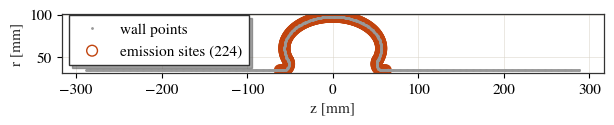

<Axes: xlabel='z [mm]', ylabel='r [mm]'>

In [5]:
mp.set_emission_points([-0.062, 0.062], n_points=60)
mp.show_emission_points()

## The sweep

Multipacting Epk sweep: 24 points on 6 processes.


Multipacting sweep:   0%|          | 0/24 [00:00<?, ?field/s]

Multipacting sweep done: 24 field levels, 8064 launch sites x phases, 267.0s (11.12s per field level).


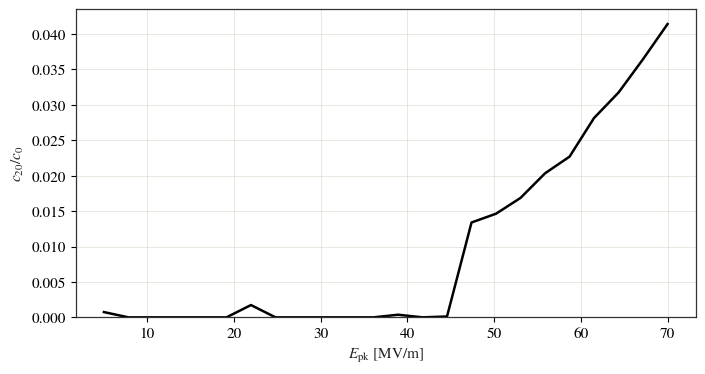

In [6]:
mp.run({'proc_count': 6, 'epks': list(1e6 * np.linspace(5, 70, 24)),
        'phis': list(np.linspace(0, 2 * np.pi, 36))})
ax = mp.plot_counter()
ax.set_title(f'Reentrant cell - peak c20/c0 = {mp.counter.max():.2f}')
plt.show()

## Watching the avalanche localise

`animate_trajectories(zoom='follow')` uses a **moving camera** that re-frames onto the electrons still alive: an initial burst across the domain is shown wide, and the view closes in as the multipacting localises at the reentrant nose. The inline player is a compact H.264 video (the whole animation, not a size-limited frame dump). Pick the field level with the strongest activity.

In [7]:
i_peak = int(np.argmax(mp.counter))
mp.animate_trajectories(epk_i=i_peak, zoom='follow')

Encoding inline video:   0%|          | 0/1147 [00:00<?, ?frame/s]

## The same avalanche in phase space

`animate_phase_space(x, y)` plays the *same* survivors as a phase-space projection — you
pick what each axis plots. Here is the impact-energy-vs-RF-phase **"bucket" view**
(`phase` vs `energy`) with `zoom='follow'`, an **adaptive camera** that re-frames each
frame onto the electrons still alive, so the cloud closes in as the multipacting locks
into resonance. Try `x='z', y='vz'` for the axial phase space. Velocities and energy are
finite-differenced from the recorded positions, so they are noisier than the positions.

In [8]:
mp.animate_phase_space(epk_i=i_peak, x='phase', y='energy', zoom='follow')   # RF bucket, adaptive camera

Encoding inline video:   0%|          | 0/1147 [00:00<?, ?frame/s]

## Where to go next

- [Multipacting: a spline cavity](spline.ipynb) and [an RF gun](rfgun.ipynb).
- [Multipacting: the TESLA mid-cell](tesla.ipynb) — the rounded cell, for contrast.
- [A gallery of cavity shapes](../eigenmode/cavity_types.ipynb).